In [1]:
from src.network_plots import *
from PIL import Image, ImageSequence

In [ ]:
savepath_TS_1_color = "../results/Network/2D"
create_folder(savepath_TS_1_color)

Folder already exists: ../results/TimeSeries/2D


P0_0.10_p0_1.00_seed_1584696902.npz
[✔] Image saved to: ../results/TimeSeries/2D/Network.pdf


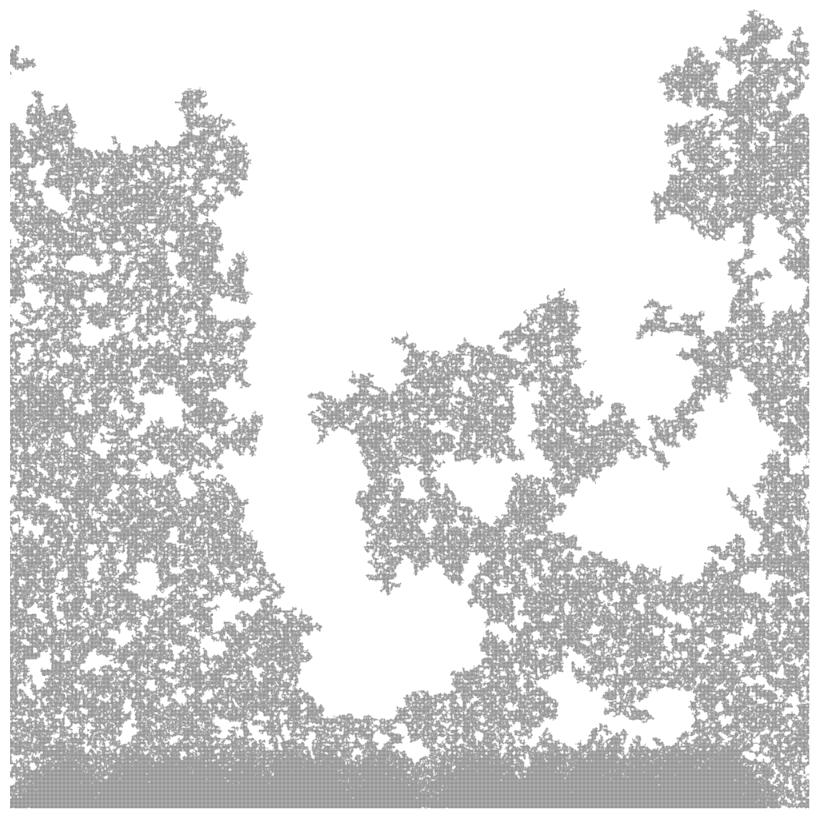

In [3]:
num_colors = 1
k = 1.0e-05
rho_val = 1.0
#path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_2/L_1000/NT_constant/NT_200/k_{k:.1e}/rho_{rho_val:.4e}/network/"
path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_2/L_1000/NT_constant/NT_200/k_{k:.1e}/rho_{rho_val:.4e}/network/"
filename = list_npz_files(path)[0]
print(filename)
plot_bond_network(
    path+filename,
    num_colors=num_colors,
    savepath=savepath_TS_1_color + f"/Network.pdf",
    dpi=600,
    min_density=1,
    color_map=None,          # dict[int,str] opcional: {valor_ativo: cor}
    linewidth=0.25,
    figsize=(8, 10),
    show_legend=True
)

P0_0.10_p0_1.00_seed_723725154.npz
[✔] Image saved to: ../results/TimeSeries/2D/Network.pdf


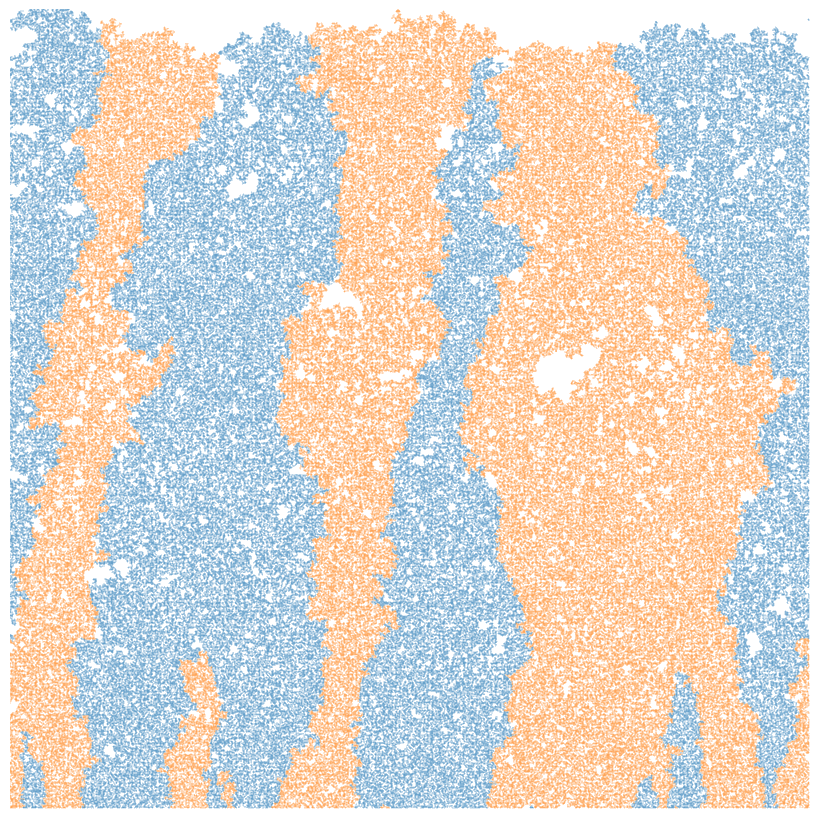

In [4]:
num_colors = 2
k = 1.0e-05
rho_val = 0.2
#path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_2/L_1000/NT_constant/NT_200/k_{k:.1e}/rho_{rho_val:.4e}/network/"
path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_2/L_1000/NT_constant/NT_200/k_{k:.1e}/rho_{rho_val:.4e}/network/"
filename = list_npz_files(path)[0]
print(filename)
plot_bond_network(
    path+filename,
    num_colors=num_colors,
    savepath=savepath_TS_1_color + f"/Network.pdf",
    dpi=600,
    min_density=1,
    color_map=None,          # dict[int,str] opcional: {valor_ativo: cor}
    linewidth=0.25,
    figsize=(8, 10),
    show_legend=True
)

In [ ]:
start_frame = 0
end_frame = 999
filepath = "../animation/P0_0.10_p0_1.00_seed_630136907.npz"
output_dir = "../animation/frames_network"
font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"  # ⬅️ Replace if needed
animation_network(start_frame, end_frame, filepath, output_dir, font_path=font_path ,font_size=50)

In [ ]:
filename = "P0_0.10_p0_1.00_seed_630136907.csv"
start_frame = 0
end_frame = 999
output_dir = "../animation/frames_properties"
animation_properties(filename, output_dir, start_frame, end_frame)

In [ ]:
# Exemplo de uso
#create_gif_with_cleanup("../animation/frames_network", "../animation/network.gif", delay=0.05)
create_gif_with_cleanup("../animation/frames_properties", "../animation/properties.gif", delay=0.05)

In [3]:
import imageio.v2 as imageio
from PIL import Image, ImageDraw, ImageFont
import os
import numpy as np

def join_gifs_side_by_side(gif_paths, output_path, title="Comparison", font_path=None, font_size=24):
    # Load all GIFs
    gif_readers = [imageio.get_reader(path) for path in gif_paths]
    num_frames = min(len(reader) for reader in gif_readers)

    # Load font
    if font_path is not None and os.path.exists(font_path):
        font = ImageFont.truetype(font_path, font_size)
    else:
        font = ImageFont.load_default()

    # Get frame sizes
    gif_sizes = [Image.open(path).size for path in gif_paths]
    total_width = sum(w for w, _ in gif_sizes)
    max_height = max(h for _, h in gif_sizes)
    title_height = font_size + 20

    # Create output writer
    with imageio.get_writer(output_path, mode="I", duration=0.05) as writer:
        for i in range(num_frames):
            # Read and convert each frame to RGB
            frames = [Image.fromarray(reader.get_data(i)).convert("RGB") for reader in gif_readers]

            # Create a new canvas
            combined = Image.new("RGB", (total_width, max_height + title_height), "white")

            # Draw title
            draw = ImageDraw.Draw(combined)
            bbox = font.getbbox(title)
            title_width = bbox[2] - bbox[0]
            draw.text(
                ((total_width - title_width) // 2, 5),
                title,
                font=font,
                fill="black"
            )

            # Paste each frame side by side
            x_offset = 0
            for frame in frames:
                combined.paste(frame, (x_offset, title_height))
                x_offset += frame.width

            # Append to GIF
            writer.append_data(np.array(combined))

    # Close readers
    for reader in gif_readers:
        reader.close()

    print(f"[✅] Combined GIF saved to {output_path}")


In [ ]:
join_gifs_side_by_side(
    gif_paths=["../animation/network.gif", "../animation/properties.gif"],
    output_path="../animation/schematic.gif",
    title=r"$p_0 = 1.0$, $L = 1000$, $k=10^{-5}$, $N_t = 200$",
    font_path="/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
    font_size=28
)


In [ ]:
# abrir os dois gifs
gif1 = Image.open("gif1.gif")
gif2 = Image.open("gif2.gif")

frames = []
for frame1, frame2 in zip(ImageSequence.Iterator(gif1), ImageSequence.Iterator(gif2)):
    # garantir que ambos tenham o mesmo modo
    f1 = frame1.convert("RGBA")
    f2 = frame2.convert("RGBA")
    
    # criar uma nova imagem lado a lado
    new_frame = Image.new("RGBA", (f1.width + f2.width, f1.height))
    new_frame.paste(f1, (0, 0))
    new_frame.paste(f2, (f1.width, 0))
    
    frames.append(new_frame)

# salvar como novo gif
frames[0].save(
    "combined.gif",
    save_all=True,
    append_images=frames[1:],
    loop=0,
    duration=gif1.info["duration"]  # mantém tempo do gif original
)